# 2D Sound Baseline v0.2

Purpose: test whether the current validated representation and fixed 2D CNN baseline show useful signal on a larger controlled subset, or still collapse to one class.

## 1. Configuration section

In [1]:
from pathlib import Path
from typing import Sequence
from datetime import datetime
import json
import re

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

try:
    from sklearn.metrics import classification_report
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False

# Core paths
output_root = Path('/home/mitch/development/raccoon-ball/training-data')
window_manifest_path = [
    Path('/home/mitch/development/raccoon-ball/training-data/-6db-pump-normal/manifests/20260319_152022_windows.parquet'),
    Path('/home/mitch/development/raccoon-ball/training-data/-6db-pump-abnormal/manifests/20260319_155015_windows.parquet'),
]
clip_manifest_path = [
    Path('/home/mitch/development/raccoon-ball/training-data/-6db-pump-normal/manifests/20260319_152022_files.parquet'),
    Path('/home/mitch/development/raccoon-ball/training-data/-6db-pump-abnormal/manifests/20260319_155015_files.parquet'),
]
machine_filter = 'pump'

# Artifact output
models_root = Path('./models')
notebook_filename_for_outputs = '2d_sound_v0.2.ipynb'

# Data selection
max_normal_clips = 100
max_abnormal_clips = 100
match_normal_to_abnormal_when_abnormal_limited = True
val_fraction = 0.2

# Training
batch_size = 32
num_epochs = 64
learning_rate = 1e-3
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Randomness
random_seed = 42

# Optional input mode comparison
# - 'normalized_plus_mask': channel 0 = normalized_window, channel 1 = active_mask.float()
# - 'normalized_only': channel 0 = normalized_window, channel 1 = zeros
input_mode = 'normalized_plus_mask'

np.random.seed(random_seed)
torch.manual_seed(random_seed)

CHECKS = {
    'larger subset built': False,
    'clip-level split applied': False,
    'training completed': False,
    'diagnostics printed': False,
    'prediction distribution computed': False,
    'confusion matrix generated': False,
    'history plots generated': False,
    'model artifacts saved': False,
}

NAN_DETECTED = False
TRAINING_EXCEPTION = None

best_val_loss = float('inf')
best_epoch = None
best_state_dict = None

MODEL_OUTPUT_DIR = None
FINAL_MODEL_PATH = None
BEST_MODEL_PATH = None
TRAINING_HISTORY_JSON_PATH = None
MODEL_CARD_PATH = None

print('Config loaded.')
print(f'input_mode={input_mode}')
print(f'device={device}, batch_size={batch_size}, num_epochs={num_epochs}, lr={learning_rate}')

Config loaded.
input_mode=normalized_plus_mask
device=cuda, batch_size=32, num_epochs=64, lr=0.001


## 2. Manifest loading, filtering, and clip-level split

In [2]:
def _to_path_list(value):
    if isinstance(value, (str, Path)):
        raw = [value]
    elif isinstance(value, Sequence):
        raw = list(value)
    else:
        raise TypeError(f'Expected Path/str or a sequence of paths, got {type(value)}')

    out = []
    for v in raw:
        p = Path(v).expanduser()
        if not p.is_absolute():
            p = (Path.cwd() / p).resolve()
        out.append(p)
    return out


def _read_parquet_many(paths, kind_name):
    dfs = []
    for p in paths:
        if not p.exists():
            raise FileNotFoundError(f'{kind_name} manifest not found: {p}')
        try:
            df = pd.read_parquet(p)
        except Exception as exc:
            raise RuntimeError(
                f'Failed to read {kind_name} parquet at {p}. Ensure pyarrow/fastparquet is installed.'
            ) from exc
        df = df.copy()
        df['_manifest_path'] = str(p)
        dfs.append(df)

    if not dfs:
        raise RuntimeError(f'No {kind_name} manifests provided.')
    return pd.concat(dfs, ignore_index=True)


def _pick_first_column(df, candidates, required=True, purpose=''):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f'Could not find required column for {purpose}. Tried: {candidates}. Available: {list(df.columns)}')
    return None


def _normalize_path_str(x):
    return str(x).replace('\\', '/')


def _resolve_npz_path(path_value, output_root_path):
    p = Path(str(path_value)).expanduser()
    candidates = []

    if p.is_absolute():
        candidates.append(p)
    else:
        candidates.append((Path.cwd() / p).resolve())
        candidates.append((output_root_path / p).resolve())
        candidates.append((output_root_path / 'tensors' / p).resolve())

    for c in candidates:
        if c.exists():
            return c
    return candidates[0]


def _label_from_text(text):
    t = str(text).lower()
    if ('abnormal' in t) or ('-ab-' in t) or re.search(r'(^|[-_/])ab($|[-_/])', t):
        return 1
    if ('normal' in t) or ('-nm-' in t) or re.search(r'(^|[-_/])nm($|[-_/])', t):
        return 0
    return None


def _infer_label(row, explicit_label_col, text_cols):
    if explicit_label_col is not None:
        v = row.get(explicit_label_col)
        if pd.notna(v):
            token = str(v).strip().lower()
            if token in {'normal', 'nm', '0', 'false', 'non_anomalous', 'non-anomalous'}:
                return 0
            if token in {'abnormal', 'ab', '1', 'true', 'anomalous', 'anomaly'}:
                return 1

    for c in text_cols:
        if c in row and pd.notna(row[c]):
            parsed = _label_from_text(row[c])
            if parsed is not None:
                return parsed
    return None


def _infer_machine(row, explicit_machine_col, text_cols):
    if explicit_machine_col is not None:
        v = row.get(explicit_machine_col)
        if pd.notna(v):
            return str(v).strip().lower()

    text = ' '.join(str(row[c]) for c in text_cols if c in row and pd.notna(row[c])).lower()
    for token in ['pump', 'fan', 'slider', 'valve']:
        if re.search(rf'(^|[-_/]){token}($|[-_/])', text) or token in text:
            return token
    return None


def _split_clip_ids(ids, val_fraction_local=0.2, seed=42):
    ids = list(dict.fromkeys([str(x) for x in ids]))
    if len(ids) == 0:
        return [], []

    rng = np.random.default_rng(seed)
    rng.shuffle(ids)

    if len(ids) < 2:
        return ids, []

    n_val = int(round(len(ids) * val_fraction_local))
    n_val = max(1, min(n_val, len(ids) - 1))
    val_ids = ids[:n_val]
    train_ids = ids[n_val:]
    return train_ids, val_ids


window_manifest_paths = _to_path_list(window_manifest_path)
clip_manifest_paths = _to_path_list(clip_manifest_path)

window_df = _read_parquet_many(window_manifest_paths, 'window')
clip_df = _read_parquet_many(clip_manifest_paths, 'clip')

if 'status' in clip_df.columns:
    clip_df = clip_df[clip_df['status'].isin(['exported', 'skipped_existing'])].copy()

if window_df.empty or clip_df.empty:
    raise RuntimeError('Window or clip manifest is empty after loading/filtering.')

clip_npz_col = _pick_first_column(
    clip_df,
    ['tensor_npz_path', 'npz_path', 'tensor_path', 'npz', 'path'],
    required=True,
    purpose='clip npz path',
)
window_npz_col = _pick_first_column(
    window_df,
    ['tensor_npz_path', 'npz_path', 'tensor_path', 'npz', 'path'],
    required=True,
    purpose='window npz path',
)
tensor_index_col = _pick_first_column(
    window_df,
    ['tensor_index', 'window_index'],
    required=True,
    purpose='window tensor index',
)

clip_df = clip_df.copy()
window_df = window_df.copy()

clip_df['_npz_path'] = clip_df[clip_npz_col].map(lambda x: str(_resolve_npz_path(x, output_root)))
window_df['_npz_path'] = window_df[window_npz_col].map(lambda x: str(_resolve_npz_path(x, output_root)))
clip_df['_npz_norm'] = clip_df['_npz_path'].map(_normalize_path_str)
window_df['_npz_norm'] = window_df['_npz_path'].map(_normalize_path_str)

clip_id_col = _pick_first_column(
    clip_df,
    ['clip_id', 'relative_source_path', 'source_file', 'tensor_npz_path'],
    required=False,
    purpose='clip identity',
)
if clip_id_col is None:
    clip_df['_clip_id'] = clip_df['_npz_path'].map(lambda p: Path(p).stem)
else:
    clip_df['_clip_id'] = clip_df[clip_id_col].astype(str)

label_col = _pick_first_column(
    clip_df,
    ['label', 'class_label', 'class', 'target', 'condition', 'anomaly_label'],
    required=False,
    purpose='label',
)
machine_col = _pick_first_column(
    clip_df,
    ['machine', 'machine_type', 'machine_name'],
    required=False,
    purpose='machine',
)

text_cols_for_inference = [
    c for c in ['source_file', 'relative_source_path', 'tensor_npz_path', '_npz_path'] if c in clip_df.columns
]
clip_df['label'] = clip_df.apply(lambda r: _infer_label(r, label_col, text_cols_for_inference), axis=1)
clip_df['machine'] = clip_df.apply(lambda r: _infer_machine(r, machine_col, text_cols_for_inference), axis=1)

missing_label_mask = clip_df['label'].isna()
if missing_label_mask.any():
    examples = clip_df.loc[missing_label_mask, text_cols_for_inference].head(5)
    msg = (
        'Could not infer normal/abnormal label for some clips. '
        'Please add a label column or use path naming containing normal/abnormal or -nm-/-ab-.'
    )
    raise RuntimeError(msg + ' Example rows: ' + examples.to_string(index=False))

clip_df['label'] = clip_df['label'].astype(int)

if machine_filter:
    mf = str(machine_filter).strip().lower()
    clip_df = clip_df[clip_df['machine'].fillna('').str.contains(mf, regex=False)].copy()

normal_candidates = clip_df[clip_df['label'] == 0].drop_duplicates('_npz_norm').sort_values('_clip_id')
abnormal_candidates = clip_df[clip_df['label'] == 1].drop_duplicates('_npz_norm').sort_values('_clip_id')

selected_abnormal_df = abnormal_candidates.head(max_abnormal_clips).copy()
if selected_abnormal_df.empty:
    raise RuntimeError('No abnormal clips were selected. Check manifests/filtering.')

if match_normal_to_abnormal_when_abnormal_limited and len(selected_abnormal_df) < max_abnormal_clips:
    target_normal_count = min(max_normal_clips, len(selected_abnormal_df))
else:
    target_normal_count = max_normal_clips

selected_normal_df = normal_candidates.head(target_normal_count).copy()
if selected_normal_df.empty:
    raise RuntimeError('No normal clips were selected. Check manifests/filtering.')

selected_clips_df = pd.concat([selected_normal_df, selected_abnormal_df], ignore_index=True)

expected_normal = min(target_normal_count, len(normal_candidates))
expected_abnormal = min(max_abnormal_clips, len(abnormal_candidates))
CHECKS['larger subset built'] = (
    len(selected_normal_df) == expected_normal
    and len(selected_abnormal_df) == expected_abnormal
    and (len(selected_normal_df) + len(selected_abnormal_df) >= 20)
)

selected_lookup = selected_clips_df[['_npz_norm', '_npz_path', '_clip_id', 'label']].drop_duplicates('_npz_norm')
window_df['tensor_index'] = window_df[tensor_index_col].astype(int)
selected_windows_df = window_df.merge(selected_lookup, on='_npz_norm', how='inner')

if selected_windows_df.empty:
    window_df['_npz_name'] = window_df['_npz_path'].map(lambda p: Path(p).name)
    selected_lookup = selected_lookup.copy()
    selected_lookup['_npz_name'] = selected_lookup['_npz_path'].map(lambda p: Path(p).name)
    selected_windows_df = window_df.merge(selected_lookup, on='_npz_name', how='inner')

if selected_windows_df.empty:
    raise RuntimeError('Selected subset produced zero window rows. Check manifest alignment.')

selected_windows_df = selected_windows_df.rename(
    columns={
        '_clip_id': 'clip_id',
        '_npz_path_y': 'npz_path',
        '_npz_path_x': 'window_npz_path',
        'label': 'label',
    }
)

if 'npz_path' not in selected_windows_df.columns:
    if '_npz_path' in selected_windows_df.columns:
        selected_windows_df['npz_path'] = selected_windows_df['_npz_path']
    elif 'window_npz_path' in selected_windows_df.columns:
        selected_windows_df['npz_path'] = selected_windows_df['window_npz_path']
    else:
        raise RuntimeError('Unable to resolve npz_path column in selected windows.')

train_clip_ids = []
val_clip_ids = []
for label_value in [0, 1]:
    class_clip_ids = selected_clips_df.loc[selected_clips_df['label'] == label_value, '_clip_id'].astype(str).tolist()
    tr_ids, va_ids = _split_clip_ids(class_clip_ids, val_fraction_local=val_fraction, seed=random_seed + label_value)
    train_clip_ids.extend(tr_ids)
    val_clip_ids.extend(va_ids)

if len(train_clip_ids) == 0 or len(val_clip_ids) == 0:
    raise RuntimeError(
        'Clip split produced an empty train or validation split. '
        'Increase selected clips so each class has at least two clips.'
    )

if set(train_clip_ids).intersection(set(val_clip_ids)):
    raise RuntimeError('Clip leakage detected: at least one clip appears in both train and validation.')

train_windows_df = selected_windows_df[selected_windows_df['clip_id'].astype(str).isin(train_clip_ids)].copy()
val_windows_df = selected_windows_df[selected_windows_df['clip_id'].astype(str).isin(val_clip_ids)].copy()

if train_windows_df.empty or val_windows_df.empty:
    raise RuntimeError('Train or validation window set is empty after clip-level split.')

CHECKS['clip-level split applied'] = True

print(f'Loaded window rows: {len(window_df):,}')
print(f'Loaded clip rows: {len(clip_df):,}')
print(f'Selected normal clips: {len(selected_normal_df)}')
print(f'Selected abnormal clips: {len(selected_abnormal_df)}')

Loaded window rows: 75,690
Loaded clip rows: 4,205
Selected normal clips: 100
Selected abnormal clips: 100


## 3. Required split diagnostics

In [3]:
def _count_by_label(df, label_col='label'):
    vc = df[label_col].value_counts().sort_index()
    return int(vc.get(0, 0)), int(vc.get(1, 0))

train_clip_df = selected_clips_df[selected_clips_df['_clip_id'].astype(str).isin(train_clip_ids)].copy()
val_clip_df = selected_clips_df[selected_clips_df['_clip_id'].astype(str).isin(val_clip_ids)].copy()

train_normal_clips, train_abnormal_clips = _count_by_label(train_clip_df, label_col='label')
val_normal_clips, val_abnormal_clips = _count_by_label(val_clip_df, label_col='label')

train_normal_windows, train_abnormal_windows = _count_by_label(train_windows_df, label_col='label')
val_normal_windows, val_abnormal_windows = _count_by_label(val_windows_df, label_col='label')

print('number of normal train clips:', train_normal_clips)
print('number of abnormal train clips:', train_abnormal_clips)
print('number of normal validation clips:', val_normal_clips)
print('number of abnormal validation clips:', val_abnormal_clips)
print('number of normal train windows:', train_normal_windows)
print('number of abnormal train windows:', train_abnormal_windows)
print('number of normal validation windows:', val_normal_windows)
print('number of abnormal validation windows:', val_abnormal_windows)

number of normal train clips: 80
number of abnormal train clips: 80
number of normal validation clips: 20
number of abnormal validation clips: 20
number of normal train windows: 1440
number of abnormal train windows: 1440
number of normal validation windows: 360
number of abnormal validation windows: 360


## 4. Dataset loader (same core behavior, optional input mode toggle)

In [4]:
class TwoChannelWindowDataset(Dataset):
    def __init__(self, rows_df: pd.DataFrame, input_mode_local: str = 'normalized_plus_mask'):
        required_cols = {'npz_path', 'tensor_index', 'label', 'clip_id'}
        missing = sorted(required_cols - set(rows_df.columns))
        if missing:
            raise ValueError(f'Dataset rows are missing required columns: {missing}')

        if input_mode_local not in {'normalized_plus_mask', 'normalized_only'}:
            raise ValueError(f'Unsupported input_mode: {input_mode_local}')

        self.rows = rows_df[['npz_path', 'tensor_index', 'label', 'clip_id']].reset_index(drop=True).copy()
        self.input_mode = input_mode_local

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows.iloc[idx]
        npz_path = Path(str(row['npz_path']))
        tensor_index = int(row['tensor_index'])
        label = int(row['label'])

        if label not in (0, 1):
            raise ValueError(f'Invalid label at idx={idx}: {label}. Expected 0 (normal) or 1 (abnormal).')
        if not npz_path.exists():
            raise FileNotFoundError(f'NPZ not found at idx={idx}: {npz_path}')

        with np.load(npz_path, allow_pickle=False) as npz:
            if 'normalized_window' not in npz.files:
                raise KeyError(f"Missing key 'normalized_window' in {npz_path}")
            if 'active_mask' not in npz.files:
                raise KeyError(f"Missing key 'active_mask' in {npz_path}")

            normalized_all = npz['normalized_window']
            active_all = npz['active_mask']

            if tensor_index < 0 or tensor_index >= normalized_all.shape[0]:
                raise IndexError(
                    f'tensor_index out of bounds for {npz_path}: index={tensor_index}, N={normalized_all.shape[0]}'
                )

            normalized_window = normalized_all[tensor_index]
            active_mask = active_all[tensor_index]

        if normalized_window.shape != (96, 64):
            raise ValueError(
                f'normalized_window shape mismatch at idx={idx}: got {normalized_window.shape}, expected (96, 64)'
            )
        if active_mask.shape != (96, 64):
            raise ValueError(
                f'active_mask shape mismatch at idx={idx}: got {active_mask.shape}, expected (96, 64)'
            )

        channel_0 = normalized_window.astype(np.float32, copy=False)
        if self.input_mode == 'normalized_plus_mask':
            channel_1 = active_mask.astype(np.float32, copy=False)
        else:
            channel_1 = np.zeros_like(channel_0, dtype=np.float32)

        x = np.stack([channel_0, channel_1], axis=0)

        if x.shape != (2, 96, 64):
            raise ValueError(f'stacked tensor shape mismatch at idx={idx}: got {x.shape}, expected (2, 96, 64)')
        if x.dtype != np.float32:
            raise TypeError(f'stacked tensor dtype mismatch at idx={idx}: got {x.dtype}, expected float32')

        return torch.from_numpy(x), torch.tensor(label, dtype=torch.long)


train_dataset = TwoChannelWindowDataset(train_windows_df, input_mode_local=input_mode)
val_dataset = TwoChannelWindowDataset(val_windows_df, input_mode_local=input_mode)

sample_x, sample_y = train_dataset[0]
print('Single sample shape:', tuple(sample_x.shape))
print('Single sample dtype:', sample_x.dtype)
print('Single sample label:', int(sample_y))
print('Input mode used:', input_mode)

Single sample shape: (2, 96, 64)
Single sample dtype: torch.float32
Single sample label: 0
Input mode used: normalized_plus_mask


## 5. Required diagnostics before training

In [5]:
def _balance_text(df):
    vc = df['label'].value_counts().sort_index()
    total = int(vc.sum()) if len(vc) else 0
    n0 = int(vc.get(0, 0))
    n1 = int(vc.get(1, 0))
    if total == 0:
        return 'normal=0 (0.00%), abnormal=0 (0.00%)'
    return f'normal={n0} ({100.0*n0/total:.2f}%), abnormal={n1} ({100.0*n1/total:.2f}%)'

pin_memory = (device == 'cuda') and torch.cuda.is_available()
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=pin_memory)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=pin_memory)

batch_x, batch_y = next(iter(train_loader))

print('1. dataset summary:')
print(f'   train windows={len(train_dataset):,}, validation windows={len(val_dataset):,}')
print('2. train/validation class balance:')
print('   train:', _balance_text(train_windows_df))
print('   validation:', _balance_text(val_windows_df))
print('3. number of clips and windows per split:')
print(f'   train clips={len(train_clip_ids)}, validation clips={len(val_clip_ids)}')
print(f'   train windows={len(train_windows_df)}, validation windows={len(val_windows_df)}')
print('4. one batch shape:', tuple(batch_x.shape))
print('5. one batch dtype:', batch_x.dtype)
print('6. one batch device:', batch_x.device)
print('7. min/max channel 0:', float(batch_x[:, 0].min()), float(batch_x[:, 0].max()))
print('8. min/max channel 1:', float(batch_x[:, 1].min()), float(batch_x[:, 1].max()))
print('9. unique labels in one batch:', torch.unique(batch_y).tolist())

CHECKS['diagnostics printed'] = True

1. dataset summary:
   train windows=2,880, validation windows=720
2. train/validation class balance:
   train: normal=1440 (50.00%), abnormal=1440 (50.00%)
   validation: normal=360 (50.00%), abnormal=360 (50.00%)
3. number of clips and windows per split:
   train clips=160, validation clips=40
   train windows=2880, validation windows=720
4. one batch shape: (32, 2, 96, 64)
5. one batch dtype: torch.float32
6. one batch device: cpu
7. min/max channel 0: 0.0 1.0
8. min/max channel 1: 0.0 1.0
9. unique labels in one batch: [0, 1]


## 6. Model (unchanged baseline architecture)

In [6]:
class Baseline2DCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(2, 16, kernel_size=5, stride=1, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Linear(64, 2)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


model = Baseline2DCNN()
with torch.no_grad():
    test_logits = model(batch_x[: min(4, len(batch_x))])
print('Forward-pass logits shape:', tuple(test_logits.shape))

Forward-pass logits shape: (4, 2)


## 7. Loss and optimization setup

In [7]:
runtime_device = torch.device(device)
if runtime_device.type == 'cuda' and not torch.cuda.is_available():
    print('CUDA requested but unavailable, falling back to CPU.')
    runtime_device = torch.device('cpu')

model = model.to(runtime_device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

param_count = sum(p.numel() for p in model.parameters())
print('Model parameter count:', param_count)
print('Runtime device:', runtime_device)

Model parameter count: 24082
Runtime device: cuda


## 8. Training loop with collapse diagnostics

In [8]:
def _check_no_nan(name, tensor):
    global NAN_DETECTED
    if torch.isnan(tensor).any():
        NAN_DETECTED = True
        raise RuntimeError(f'NaN detected in {name}')


def _safe_div(a, b):
    return float(a) / float(b) if b else 0.0


history = {
    'epoch': [],
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_pred_normal': [],
    'val_pred_abnormal': [],
    'val_pred_normal_prop': [],
    'val_pred_abnormal_prop': [],
}

for epoch in range(1, num_epochs + 1):
    try:
        model.train()
        train_loss_sum = 0.0
        train_correct = 0
        train_total = 0

        for x, y in train_loader:
            x = x.to(runtime_device, non_blocking=True)
            y = y.to(runtime_device, non_blocking=True)

            _check_no_nan('train inputs', x)

            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            _check_no_nan('train logits', logits)

            loss = criterion(logits, y)
            if torch.isnan(loss):
                NAN_DETECTED = True
                raise RuntimeError('NaN detected in train loss')

            loss.backward()
            optimizer.step()

            train_loss_sum += float(loss.item()) * x.size(0)
            preds = torch.argmax(logits, dim=1)
            train_correct += int((preds == y).sum().item())
            train_total += int(y.size(0))

        train_loss = _safe_div(train_loss_sum, train_total)
        train_acc = _safe_div(train_correct, train_total)

        model.eval()
        val_loss_sum = 0.0
        val_correct = 0
        val_total = 0
        val_pred_normal = 0
        val_pred_abnormal = 0

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(runtime_device, non_blocking=True)
                y = y.to(runtime_device, non_blocking=True)

                _check_no_nan('validation inputs', x)

                logits = model(x)
                _check_no_nan('validation logits', logits)

                loss = criterion(logits, y)
                if torch.isnan(loss):
                    NAN_DETECTED = True
                    raise RuntimeError('NaN detected in validation loss')

                preds = torch.argmax(logits, dim=1)

                val_loss_sum += float(loss.item()) * x.size(0)
                val_correct += int((preds == y).sum().item())
                val_total += int(y.size(0))
                val_pred_normal += int((preds == 0).sum().item())
                val_pred_abnormal += int((preds == 1).sum().item())

        val_loss = _safe_div(val_loss_sum, val_total)
        val_acc = _safe_div(val_correct, val_total)
        val_pred_normal_prop = _safe_div(val_pred_normal, val_total)
        val_pred_abnormal_prop = _safe_div(val_pred_abnormal, val_total)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_pred_normal'].append(val_pred_normal)
        history['val_pred_abnormal'].append(val_pred_abnormal)
        history['val_pred_normal_prop'].append(val_pred_normal_prop)
        history['val_pred_abnormal_prop'].append(val_pred_abnormal_prop)

        print(
            f'Epoch {epoch:02d}/{num_epochs} | '
            f'train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | '
            f'val_loss={val_loss:.4f}, val_acc={val_acc:.4f} | '
            f'val_pred_normal={val_pred_normal}, val_pred_abnormal={val_pred_abnormal}, '
            f'val_pred_normal_prop={val_pred_normal_prop:.4f}, val_pred_abnormal_prop={val_pred_abnormal_prop:.4f}'
        )

    except Exception as exc:
        TRAINING_EXCEPTION = exc
        print(f'Training stopped with error: {type(exc).__name__}: {exc}')
        break


if TRAINING_EXCEPTION is None and len(history['epoch']) == num_epochs:
    CHECKS['training completed'] = True

if len(history['epoch']) > 0:
    CHECKS['prediction distribution computed'] = True

if NAN_DETECTED:
    print('NaN detected during training. Please patch before proceeding.')

Epoch 01/64 | train_loss=0.6942, train_acc=0.4997 | val_loss=0.6920, val_acc=0.5000 | val_pred_normal=720, val_pred_abnormal=0, val_pred_normal_prop=1.0000, val_pred_abnormal_prop=0.0000
Epoch 02/64 | train_loss=0.6912, train_acc=0.5337 | val_loss=0.6826, val_acc=0.5264 | val_pred_normal=701, val_pred_abnormal=19, val_pred_normal_prop=0.9736, val_pred_abnormal_prop=0.0264
Epoch 03/64 | train_loss=0.6530, train_acc=0.6062 | val_loss=0.6096, val_acc=0.6042 | val_pred_normal=79, val_pred_abnormal=641, val_pred_normal_prop=0.1097, val_pred_abnormal_prop=0.8903
Epoch 04/64 | train_loss=0.5399, train_acc=0.7340 | val_loss=0.4375, val_acc=0.8250 | val_pred_normal=342, val_pred_abnormal=378, val_pred_normal_prop=0.4750, val_pred_abnormal_prop=0.5250
Epoch 05/64 | train_loss=0.4898, train_acc=0.7778 | val_loss=0.4985, val_acc=0.7139 | val_pred_normal=248, val_pred_abnormal=472, val_pred_normal_prop=0.3444, val_pred_abnormal_prop=0.6556
Epoch 06/64 | train_loss=0.4537, train_acc=0.8035 | val_los

## 9. Required outputs after training

final train loss: 0.274846024148994
final validation loss: 0.24379270246459378
final train accuracy: 0.8920138888888889
final validation accuracy: 0.8875
evaluation train loss: 0.2588631331920624
evaluation validation loss: 0.24379270246459378
confusion matrix:


,pred_normal,pred_abnormal
true_normal,316,44
true_abnormal,37,323


prediction distribution on validation set:
predicted normal=353, predicted abnormal=367
predicted normal proportion=0.4903, predicted abnormal proportion=0.5097
classification report (validation):
              precision    recall  f1-score   support

      normal     0.8952    0.8778    0.8864       360
    abnormal     0.8801    0.8972    0.8886       360

    accuracy                         0.8875       720
   macro avg     0.8876    0.8875    0.8875       720
weighted avg     0.8876    0.8875    0.8875       720



,epoch,train_loss,train_acc,val_loss,val_acc,val_pred_normal,val_pred_abnormal,val_pred_normal_prop,val_pred_abnormal_prop
54,55,0.317411,0.869097,0.240953,0.901389,371,349,0.515278,0.484722
55,56,0.323517,0.867014,0.354423,0.813889,284,436,0.394444,0.605556
56,57,0.318339,0.860417,0.248694,0.888889,370,350,0.513889,0.486111
57,58,0.301140,0.876042,0.324181,0.841667,286,434,0.397222,0.602778
58,59,0.295208,0.881944,0.245797,0.900000,390,330,0.541667,0.458333
59,60,0.299230,0.876736,0.453744,0.786111,206,514,0.286111,0.713889
60,61,0.304141,0.878472,0.511093,0.756944,185,535,0.256944,0.743056
61,62,0.315543,0.864236,0.238673,0.909722,359,361,0.498611,0.501389
62,63,0.292160,0.877778,0.500861,0.776389,201,519,0.279167,0.720833
63,64,0.274846,0.892014,0.243793,0.887500,353,367,0.490278,0.509722


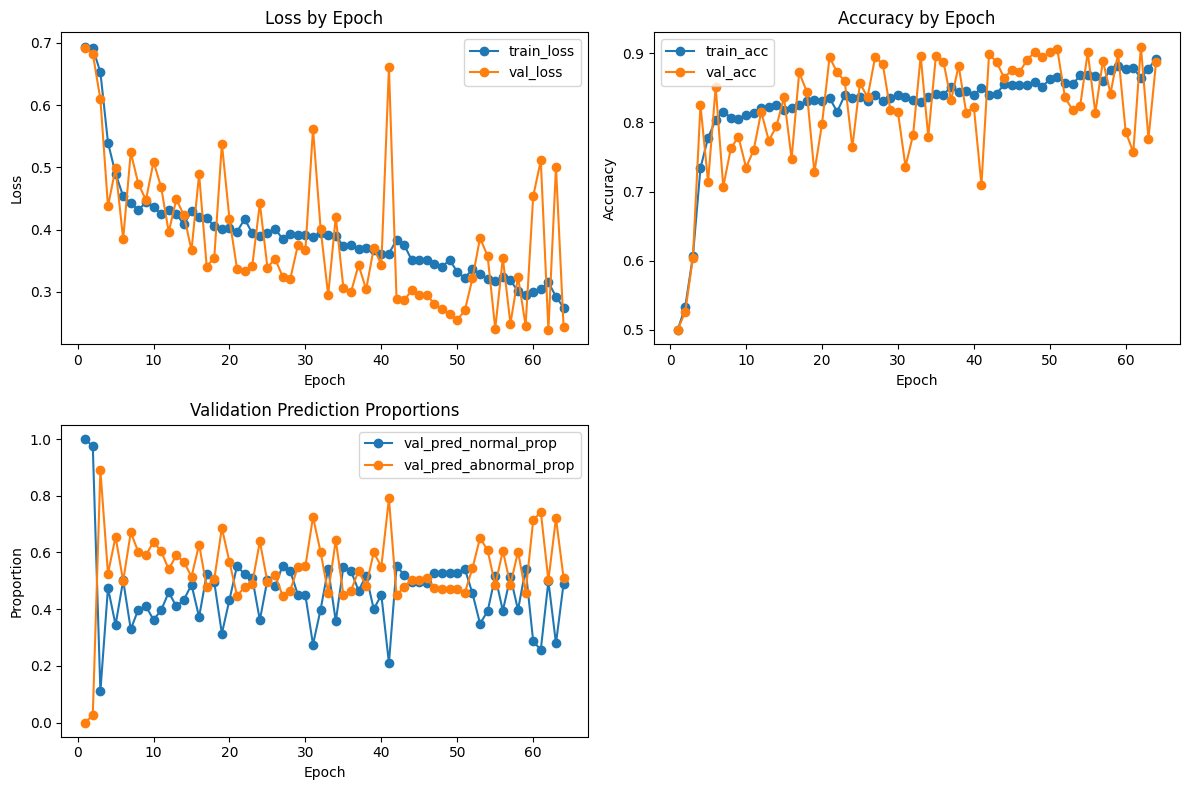

In [9]:
def _evaluate_loader(loader):
    model.eval()
    y_true = []
    y_pred = []
    loss_sum = 0.0
    count = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(runtime_device, non_blocking=True)
            y = y.to(runtime_device, non_blocking=True)
            logits = model(x)
            loss = criterion(logits, y)
            preds = torch.argmax(logits, dim=1)

            y_true.extend(y.cpu().numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())
            loss_sum += float(loss.item()) * x.size(0)
            count += int(x.size(0))

    return np.asarray(y_true, dtype=np.int64), np.asarray(y_pred, dtype=np.int64), (loss_sum / max(1, count))


def _confusion_matrix_binary(y_true, y_pred):
    cm = np.zeros((2, 2), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        if t in (0, 1) and p in (0, 1):
            cm[t, p] += 1
    return cm


if history['epoch']:
    final_train_loss = history['train_loss'][-1]
    final_val_loss_from_epoch = history['val_loss'][-1]
    final_train_acc = history['train_acc'][-1]
    final_val_acc = history['val_acc'][-1]
else:
    final_train_loss = float('nan')
    final_val_loss_from_epoch = float('nan')
    final_train_acc = float('nan')
    final_val_acc = float('nan')

val_y_true, val_y_pred, eval_val_loss = _evaluate_loader(val_loader)
train_y_true, train_y_pred, eval_train_loss = _evaluate_loader(train_loader)

cm = _confusion_matrix_binary(val_y_true, val_y_pred)
confusion_df = pd.DataFrame(
    cm,
    index=['true_normal', 'true_abnormal'],
    columns=['pred_normal', 'pred_abnormal'],
)
CHECKS['confusion matrix generated'] = True

pred_normal = int((val_y_pred == 0).sum())
pred_abnormal = int((val_y_pred == 1).sum())
pred_total = int(len(val_y_pred))
pred_normal_prop = pred_normal / pred_total if pred_total else 0.0
pred_abnormal_prop = pred_abnormal / pred_total if pred_total else 0.0

print('final train loss:', final_train_loss)
print('final validation loss:', final_val_loss_from_epoch)
print('final train accuracy:', final_train_acc)
print('final validation accuracy:', final_val_acc)
print('evaluation train loss:', eval_train_loss)
print('evaluation validation loss:', eval_val_loss)
print('confusion matrix:')
display(confusion_df)
print('prediction distribution on validation set:')
print(f'predicted normal={pred_normal}, predicted abnormal={pred_abnormal}')
print(f'predicted normal proportion={pred_normal_prop:.4f}, predicted abnormal proportion={pred_abnormal_prop:.4f}')

classification_report_text = None
classification_report_dict = None
if SKLEARN_AVAILABLE:
    print('classification report (validation):')
    classification_report_text = classification_report(
        val_y_true,
        val_y_pred,
        labels=[0, 1],
        target_names=['normal', 'abnormal'],
        digits=4,
        zero_division=0,
    )
    print(classification_report_text)
    classification_report_dict = classification_report(
        val_y_true,
        val_y_pred,
        labels=[0, 1],
        target_names=['normal', 'abnormal'],
        output_dict=True,
        zero_division=0,
    )
else:
    print('sklearn.metrics not available; skipping classification report.')

history_df = pd.DataFrame(history)
display(history_df.tail(min(10, len(history_df))))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(history['epoch'], history['train_loss'], marker='o', label='train_loss')
axes[0, 0].plot(history['epoch'], history['val_loss'], marker='o', label='val_loss')
axes[0, 0].set_title('Loss by Epoch')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

axes[0, 1].plot(history['epoch'], history['train_acc'], marker='o', label='train_acc')
axes[0, 1].plot(history['epoch'], history['val_acc'], marker='o', label='val_acc')
axes[0, 1].set_title('Accuracy by Epoch')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()

axes[1, 0].plot(history['epoch'], history['val_pred_normal_prop'], marker='o', label='val_pred_normal_prop')
axes[1, 0].plot(history['epoch'], history['val_pred_abnormal_prop'], marker='o', label='val_pred_abnormal_prop')
axes[1, 0].set_title('Validation Prediction Proportions')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Proportion')
axes[1, 0].legend()

axes[1, 1].axis('off')

fig.tight_layout()
plt.show()

CHECKS['history plots generated'] = True

## 10. Required experiment interpretation block

In [10]:
tn, fp = int(cm[0, 0]), int(cm[0, 1])
fn, tp = int(cm[1, 0]), int(cm[1, 1])

normal_recall = tn / (tn + fp) if (tn + fp) else 0.0
abnormal_recall = tp / (tp + fn) if (tp + fn) else 0.0

collapse_detected = (pred_normal == 0 or pred_abnormal == 0 or max(pred_normal_prop, pred_abnormal_prop) >= 0.95)

if collapse_detected:
    interpretation_category = 'A. Pipeline works, model still collapses'
elif final_val_acc >= 0.65 and normal_recall > 0.0 and abnormal_recall > 0.0:
    interpretation_category = 'C. Pipeline works, meaningful signal emerging'
elif final_val_acc > 0.50 and normal_recall > 0.0 and abnormal_recall > 0.0:
    interpretation_category = 'B. Pipeline works, weak but nontrivial signal'
else:
    interpretation_category = 'A. Pipeline works, model still collapses'

print('Interpretation category:', interpretation_category)
print(f'normal_recall={normal_recall:.4f}, abnormal_recall={abnormal_recall:.4f}, val_acc={final_val_acc:.4f}')

Interpretation category: C. Pipeline works, meaningful signal emerging
normal_recall=0.8778, abnormal_recall=0.8972, val_acc=0.8875


## 11. Save Models, History JSON, and Model Card

In [ ]:
run_timestamp = datetime.now().strftime('%Y%m%d-%H%M')
run_notebook_stem = Path(notebook_filename_for_outputs).stem
MODEL_OUTPUT_DIR = models_root / f'{run_timestamp}-{run_notebook_stem}'
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FINAL_MODEL_PATH = MODEL_OUTPUT_DIR / 'final_model_state_dict.pt'
BEST_MODEL_PATH = MODEL_OUTPUT_DIR / 'best_val_model_state_dict.pt'
TRAINING_HISTORY_JSON_PATH = MODEL_OUTPUT_DIR / 'training_history.json'
MODEL_CARD_PATH = MODEL_OUTPUT_DIR / 'model_card.md'

final_checkpoint = {
    'model_state_dict': model.state_dict(),
    'input_mode': input_mode,
    'epoch_count_ran': len(history['epoch']),
    'random_seed': random_seed,
    'learning_rate': learning_rate,
    'batch_size': batch_size,
    'num_epochs_config': num_epochs,
    'device': str(runtime_device),
}

torch.save(final_checkpoint, FINAL_MODEL_PATH)

if best_state_dict is None:
    best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    best_epoch = history['epoch'][-1] if history['epoch'] else None

best_checkpoint = {
    'model_state_dict': best_state_dict,
    'best_val_loss': float(best_val_loss) if best_val_loss != float('inf') else None,
    'best_epoch': int(best_epoch) if best_epoch is not None else None,
    'input_mode': input_mode,
    'random_seed': random_seed,
    'learning_rate': learning_rate,
    'batch_size': batch_size,
    'num_epochs_config': num_epochs,
    'device': str(runtime_device),
}

torch.save(best_checkpoint, BEST_MODEL_PATH)

history_payload = {
    'run_id': MODEL_OUTPUT_DIR.name,
    'notebook': str(notebook_filename_for_outputs),
    'input_mode': input_mode,
    'machine_filter': machine_filter,
    'random_seed': random_seed,
    'hyperparameters': {
        'batch_size': batch_size,
        'num_epochs_config': num_epochs,
        'learning_rate': learning_rate,
        'device': str(runtime_device),
    },
    'subset_summary': {
        'selected_normal_clips': int(len(selected_normal_df)),
        'selected_abnormal_clips': int(len(selected_abnormal_df)),
        'train_normal_clips': int(train_normal_clips),
        'train_abnormal_clips': int(train_abnormal_clips),
        'val_normal_clips': int(val_normal_clips),
        'val_abnormal_clips': int(val_abnormal_clips),
        'train_normal_windows': int(train_normal_windows),
        'train_abnormal_windows': int(train_abnormal_windows),
        'val_normal_windows': int(val_normal_windows),
        'val_abnormal_windows': int(val_abnormal_windows),
    },
    'history': history,
    'final_metrics': {
        'final_train_loss': float(final_train_loss),
        'final_val_loss_from_epoch': float(final_val_loss_from_epoch),
        'eval_train_loss': float(eval_train_loss),
        'eval_val_loss': float(eval_val_loss),
        'final_train_accuracy': float(final_train_acc),
        'final_val_accuracy': float(final_val_acc),
        'pred_normal_count': int(pred_normal),
        'pred_abnormal_count': int(pred_abnormal),
        'pred_normal_prop': float(pred_normal_prop),
        'pred_abnormal_prop': float(pred_abnormal_prop),
    },
    'confusion_matrix': cm.tolist(),
    'classification_report': classification_report_dict,
    'interpretation_category': interpretation_category,
    'checklist': CHECKS,
}

TRAINING_HISTORY_JSON_PATH.write_text(json.dumps(history_payload, indent=2))

model_card = f"""# Model Card (Brief)

## Model
- Name: `Baseline2DCNN`
- Source notebook: `{notebook_filename_for_outputs}`
- Architecture: Conv2d(2->16, k5) + ReLU + MaxPool, Conv2d(16->32, k3) + ReLU + MaxPool, Conv2d(32->64, k3) + ReLU + MaxPool, AdaptiveAvgPool2d(1,1), Linear(64->2)

## Task
- Binary machine-sound classification on pump clips
- Labels: `normal=0`, `abnormal=1`

## Inputs
- Base representation: `normalized_window` shape `(96, 64)` and `active_mask` shape `(96, 64)`
- Input mode: `{input_mode}`
- Final tensor shape: `(2, 96, 64)`

## Data & Split
- Clip-level split only (no window-level random split)
- Selected clips: normal={len(selected_normal_df)}, abnormal={len(selected_abnormal_df)}
- Train clips: normal={train_normal_clips}, abnormal={train_abnormal_clips}
- Validation clips: normal={val_normal_clips}, abnormal={val_abnormal_clips}
- Train windows: normal={train_normal_windows}, abnormal={train_abnormal_windows}
- Validation windows: normal={val_normal_windows}, abnormal={val_abnormal_windows}

## Training
- Epochs configured: {num_epochs}
- Epochs completed: {len(history['epoch'])}
- Batch size: {batch_size}
- Learning rate: {learning_rate}
- Device: {runtime_device}
- Random seed: {random_seed}

## Results (This Run)
- Final train accuracy: {final_train_acc:.4f}
- Final validation accuracy: {final_val_acc:.4f}
- Final validation loss: {final_val_loss_from_epoch:.4f}
- Predicted distribution (val): normal={pred_normal} ({pred_normal_prop:.4f}), abnormal={pred_abnormal} ({pred_abnormal_prop:.4f})
- Interpretation: {interpretation_category}

## Artifacts
- Final model checkpoint: `{FINAL_MODEL_PATH.name}`
- Best-val checkpoint: `{BEST_MODEL_PATH.name}`
- Training history JSON: `{TRAINING_HISTORY_JSON_PATH.name}`
"""

MODEL_CARD_PATH.write_text(model_card)

CHECKS['model artifacts saved'] = True

print('Saved artifacts to:', MODEL_OUTPUT_DIR)
print(' -', FINAL_MODEL_PATH)
print(' -', BEST_MODEL_PATH)
print(' -', TRAINING_HISTORY_JSON_PATH)
print(' -', MODEL_CARD_PATH)

## 12. Final verdict section

In [11]:
print('PASS / READY')
pass_items = [k for k, v in CHECKS.items() if v]
if pass_items:
    for item in pass_items:
        print(f'- {item}')
else:
    print('- none')

print('')
print('FAIL / PATCH REQUIRED')
fail_items = [k for k, v in CHECKS.items() if not v]
if fail_items:
    for item in fail_items:
        print(f'- {item}')
else:
    print('- none')

if NAN_DETECTED:
    print('- NaN detected during training/evaluation')
if TRAINING_EXCEPTION is not None:
    print(f'- training_exception: {type(TRAINING_EXCEPTION).__name__}: {TRAINING_EXCEPTION}')

final_machine_verdict = 'READY_FOR_NEXT_DECISION' if (not fail_items and not NAN_DETECTED and TRAINING_EXCEPTION is None) else 'PATCH_REQUIRED'
print('')
print('FINAL_VERDICT:', final_machine_verdict)
print(final_machine_verdict)

PASS / READY
- larger subset built
- clip-level split applied
- training completed
- diagnostics printed
- prediction distribution computed
- confusion matrix generated
- history plots generated

FAIL / PATCH REQUIRED
- none

FINAL_VERDICT: READY_FOR_NEXT_DECISION
READY_FOR_NEXT_DECISION
